In [15]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("../egg_analysis.db")

df_kape = pd.read_sql("SELECT * FROM kamis_egg_retail", conn)
df_ecos = pd.read_sql("SELECT * FROM ecos_ppi", conn)

print(df_kape.dtypes)

# 날짜 컬럼 datetime 복원
df_kape['year_month'] = pd.to_datetime(df_kape['year_month'])
df_ecos['year_month'] = pd.to_datetime(df_ecos['year_month'])

print(df_kape.head())
print(df_ecos.head())

year_month      str
egg_price     int64
dtype: object
  year_month  egg_price
0 2016-01-01       5493
1 2016-02-01       5473
2 2016-03-01       5260
3 2016-04-01       5259
4 2016-05-01       5216
  year_month  egg_ppi  electricity_ppi  feed_ppi  egg_cpi
0 2016-01-01    92.17            98.81     95.69   92.594
1 2016-02-01    85.08            98.81     95.69   91.098
2 2016-03-01    83.52            98.81     94.82   87.269
3 2016-04-01    89.81            98.81     94.82   86.773
4 2016-05-01    85.53            98.81     94.82   84.645


In [16]:
df = pd.merge(df_kape, df_ecos, on='year_month', how='inner')

print(df.shape)  
print(df.head())
print(df.isnull().sum())

(120, 6)
  year_month  egg_price  egg_ppi  electricity_ppi  feed_ppi  egg_cpi
0 2016-01-01       5493    92.17            98.81     95.69   92.594
1 2016-02-01       5473    85.08            98.81     95.69   91.098
2 2016-03-01       5260    83.52            98.81     94.82   87.269
3 2016-04-01       5259    89.81            98.81     94.82   86.773
4 2016-05-01       5216    85.53            98.81     94.82   84.645
year_month         0
egg_price          0
egg_ppi            0
electricity_ppi    0
feed_ppi           0
egg_cpi            0
dtype: int64


In [17]:
print(df.describe())

                year_month    egg_price     egg_ppi  electricity_ppi  \
count                  120   120.000000  120.000000       120.000000   
mean   2020-12-15 18:00:00  6141.883333  129.260000       119.218917   
min    2016-01-01 00:00:00  4037.000000   59.600000        97.200000   
25%    2018-06-23 12:00:00  5323.500000   98.702500       100.000000   
50%    2020-12-16 12:00:00  6313.500000  139.965000       100.000000   
75%    2023-06-08 12:00:00  6704.000000  153.687500       148.880000   
max    2025-12-01 00:00:00  9096.000000  196.800000       174.670000   
std                    NaN   931.262856   34.069246        28.702335   

         feed_ppi     egg_cpi  
count  120.000000  120.000000  
mean   114.028333  118.554850  
min     94.380000   82.984000  
25%     95.907500   97.403000  
50%    100.440000  131.400000  
75%    134.067500  136.585000  
max    145.600000  154.350000  
std     19.163926   22.309603  


In [18]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   year_month       120 non-null    datetime64[us]
 1   egg_price        120 non-null    int64         
 2   egg_ppi          120 non-null    float64       
 3   electricity_ppi  120 non-null    float64       
 4   feed_ppi         120 non-null    float64       
 5   egg_cpi          120 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 5.8 KB
None


In [19]:
import matplotlib.font_manager as fm
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

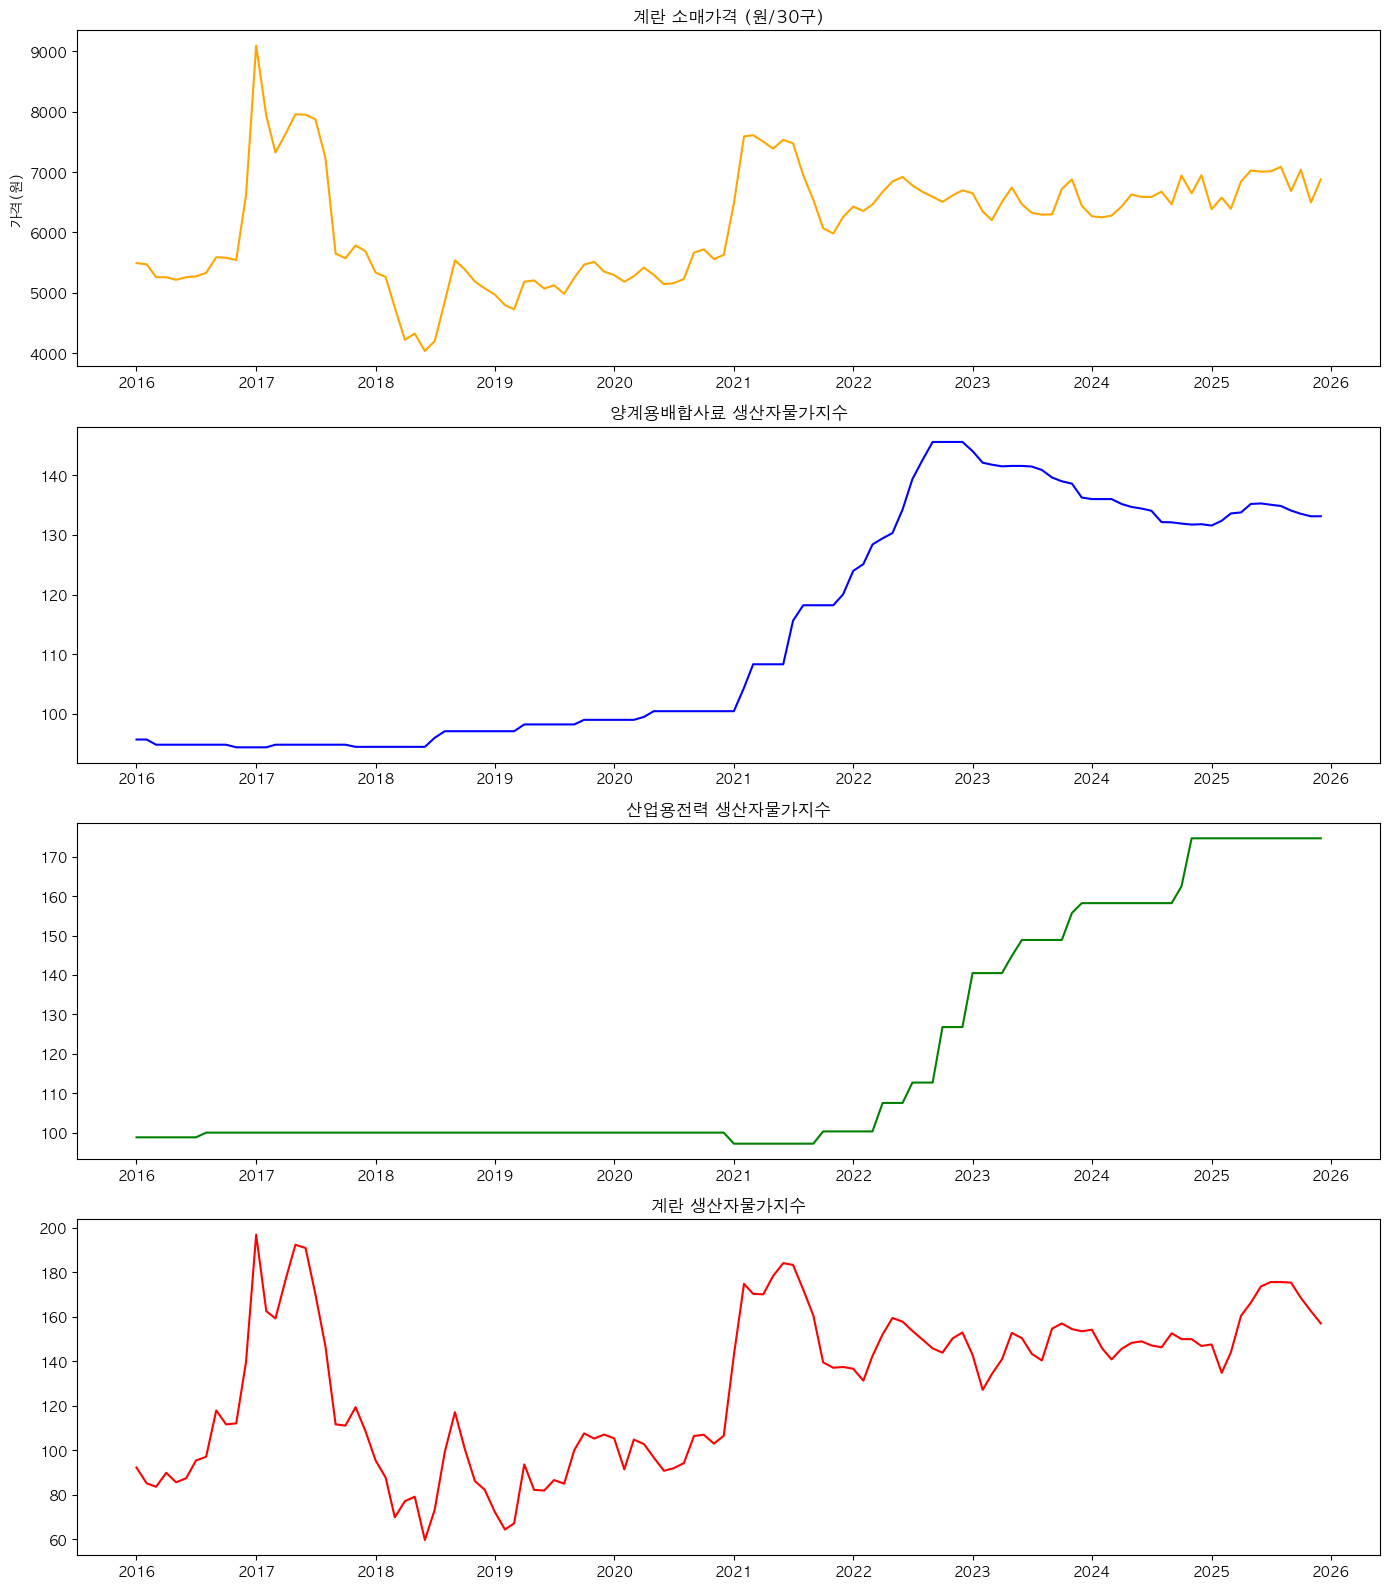

In [20]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# 계란 소매가격
axes[0].plot(df['year_month'], df['egg_price'], color='orange')
axes[0].set_title('계란 소매가격 (원/30구)')
axes[0].set_ylabel('가격(원)')

# 사료 생산자물가
axes[1].plot(df['year_month'], df['feed_ppi'], color='blue')
axes[1].set_title('양계용배합사료 생산자물가지수')

# 전력 생산자물가
axes[2].plot(df['year_month'], df['electricity_ppi'], color='green')
axes[2].set_title('산업용전력 생산자물가지수')

# 계란 생산자물가
axes[3].plot(df['year_month'], df['egg_ppi'], color='red')
axes[3].set_title('계란 생산자물가지수')

plt.tight_layout()
plt.savefig('../output/figures/time_series_all.png', dpi=150)
plt.show()

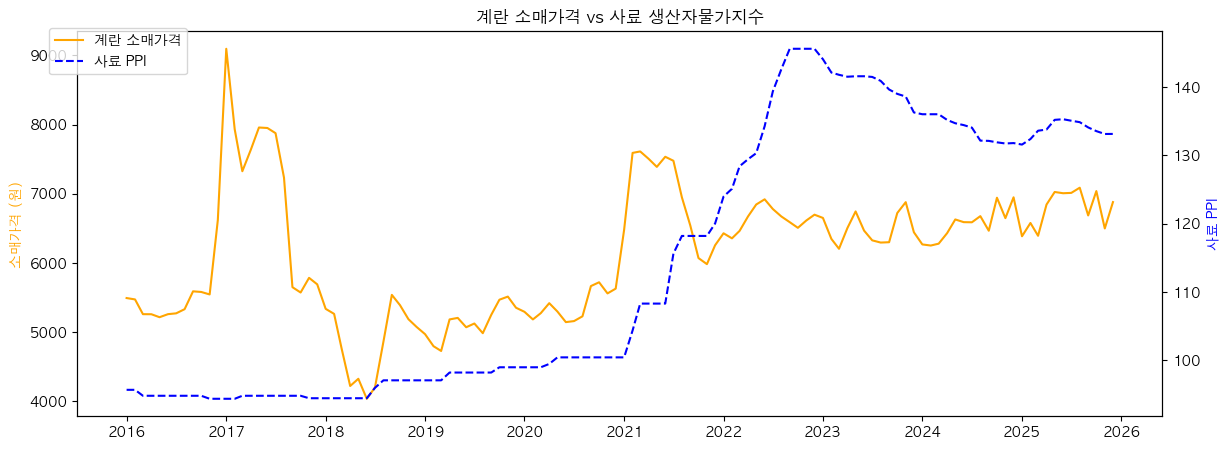

In [21]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(df['year_month'], df['egg_price'],
         color='orange', label='계란 소매가격')
ax1.set_ylabel('소매가격 (원)', color='orange')

ax2 = ax1.twinx()
ax2.plot(df['year_month'], df['feed_ppi'],
         color='blue', linestyle='--', label='사료 PPI')
ax2.set_ylabel('사료 PPI', color='blue')

plt.title('계란 소매가격 vs 사료 생산자물가지수')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.savefig('../output/figures/egg_vs_feed.png', dpi=150)
plt.show()

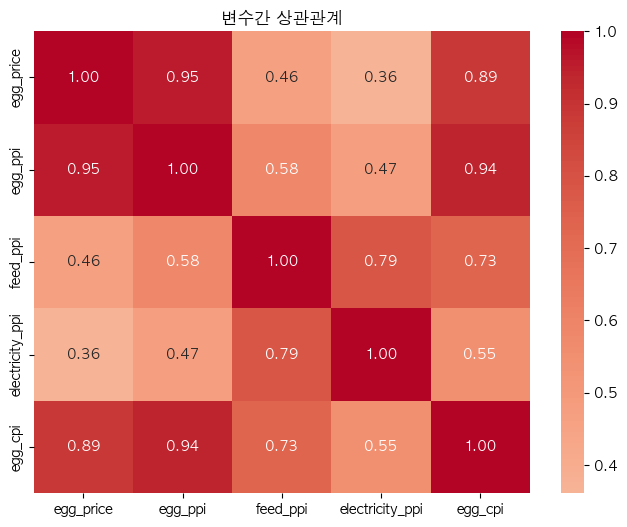

In [22]:
corr = df[['egg_price', 'egg_ppi', 'feed_ppi',
           'electricity_ppi', 'egg_cpi']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('변수간 상관관계')
plt.savefig('../output/figures/correlation_heatmap.png', dpi=150)
plt.show()

급등락 구간:
   year_month  egg_price  price_change_pct
11 2016-12-01       6621         19.404869
12 2017-01-01       9096         37.381060
13 2017-02-01       7932        -12.796834
20 2017-09-01       5650        -21.885801
27 2018-04-01       4222        -11.227923
31 2018-08-01       4860         15.714286
32 2018-09-01       5539         13.971193
60 2021-01-01       6481         15.135903
61 2021-02-01       7591         17.126987


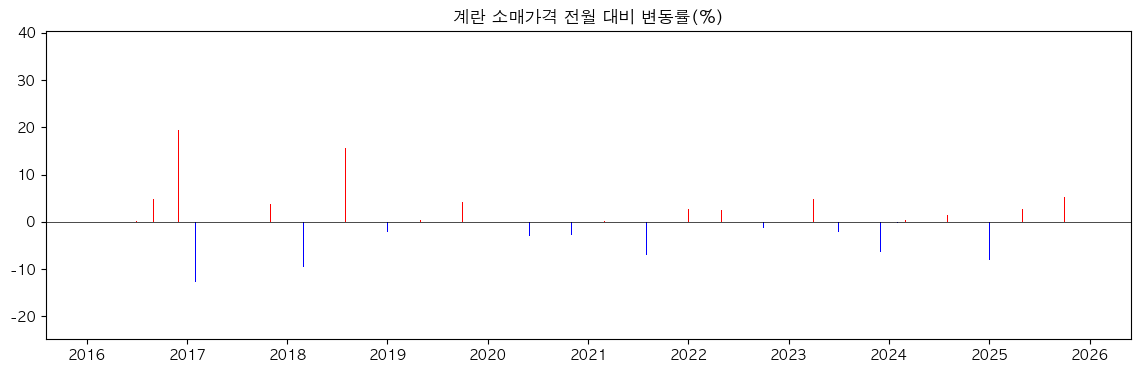

In [12]:
# 전월 대비 가격 변동률
df['price_change_pct'] = df['egg_price'].pct_change() * 100

# 변동률 큰 구간 확인 (±10% 이상)
outliers = df[df['price_change_pct'].abs() > 10]
print("급등락 구간:")
print(outliers[['year_month', 'egg_price', 'price_change_pct']])

plt.figure(figsize=(14, 4))
plt.bar(df['year_month'], df['price_change_pct'],
        color=df['price_change_pct'].apply(
            lambda x: 'red' if x > 0 else 'blue'))
plt.axhline(y=0, color='black', linewidth=0.5)
plt.title('계란 소매가격 전월 대비 변동률(%)')
plt.savefig('../output/figures/price_change.png', dpi=150)
plt.show()

In [25]:
# 사료비 및 전력 시차별 상관계수 확인
print("=== 사료비 시차별 상관계수 ===")
for lag in range(7):
    corr = df['egg_price'].corr(df['feed_ppi'].shift(lag))
    print(f"사료비 {lag}개월 시차: {corr:.3f}")

print("\n=== 전력 시차별 상관계수 ===")
for lag in range(7):
    corr = df['egg_price'].corr(df['electricity_ppi'].shift(lag))
    print(f"전력 {lag}개월 시차: {corr:.3f}")

=== 사료비 시차별 상관계수 ===
사료비 0개월 시차: 0.462
사료비 1개월 시차: 0.446
사료비 2개월 시차: 0.433
사료비 3개월 시차: 0.420
사료비 4개월 시차: 0.409
사료비 5개월 시차: 0.397
사료비 6개월 시차: 0.384

=== 전력 시차별 상관계수 ===
전력 0개월 시차: 0.361
전력 1개월 시차: 0.352
전력 2개월 시차: 0.345
전력 3개월 시차: 0.340
전력 4개월 시차: 0.335
전력 5개월 시차: 0.329
전력 6개월 시차: 0.322


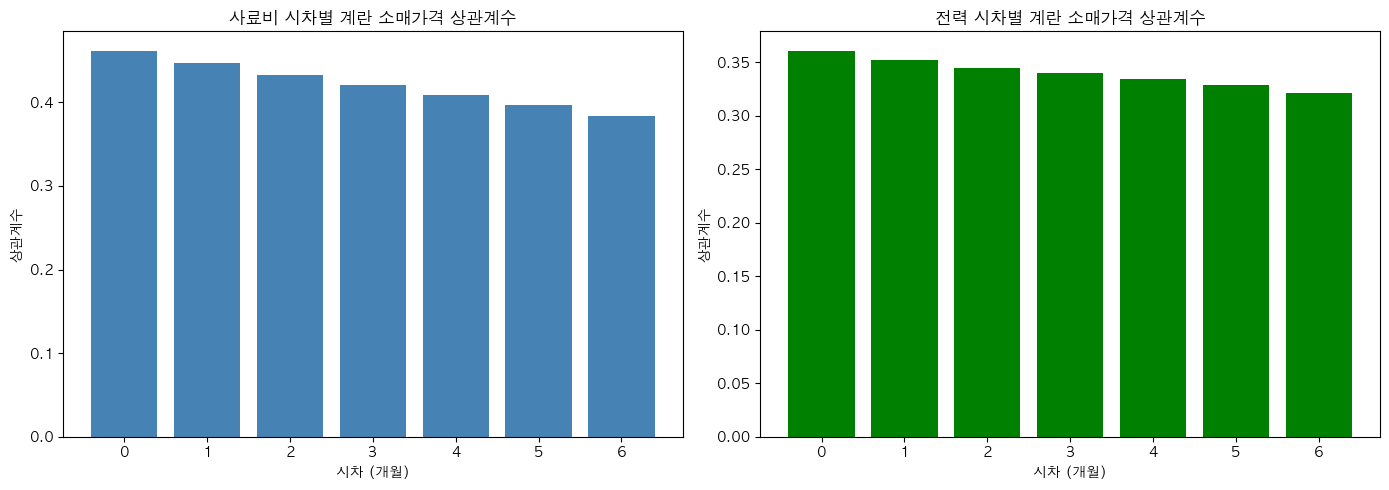

In [26]:
# 시차별 상관계수 시각화
lags = range(7)

feed_corrs = [df['egg_price'].corr(df['feed_ppi'].shift(lag)) for lag in lags]
elec_corrs = [df['egg_price'].corr(df['electricity_ppi'].shift(lag)) for lag in lags]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사료비
axes[0].bar(lags, feed_corrs, color='steelblue')
axes[0].set_xlabel('시차 (개월)')
axes[0].set_ylabel('상관계수')
axes[0].set_title('사료비 시차별 계란 소매가격 상관계수')
axes[0].set_xticks(list(lags))

# 전력
axes[1].bar(lags, elec_corrs, color='green')
axes[1].set_xlabel('시차 (개월)')
axes[1].set_ylabel('상관계수')
axes[1].set_title('전력 시차별 계란 소매가격 상관계수')
axes[1].set_xticks(list(lags))

plt.tight_layout()
plt.savefig('../output/figures/lag_correlation.png', dpi=150)
plt.show()